In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, matthews_corrcoef
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns

In [2]:
df_test = pd.read_csv("test_data.csv")
df_test

,CHEMBLID,smiles,ido_ic50,tdo_ic50
0,1a,O=S(C(N1)=CC2=C1C=CC=C2)CC3=CC=C(C(F)(F)F)C=C3,5.000000,5.000000
1,1b,O=S(C1=CC2=CC=CC=C2O1)CC3=CC=C(C(F)(F)F)C=C3,5.000000,5.000000
2,1c,O=S(C1=NC2=CC=CC=C2N1)CC3=CC=C(C(F)(F)F)C=C3,5.000000,5.000000
3,1d,O=S(C1=NC2=CC=CC=C2O1)CC3=CC=C(C(F)(F)F)C=C3,5.552842,5.000000
4,1e,O=S(C1=NC2=CC=C(Cl)C=C2O1)CC3=CC=CC=C3C(F)(F)F,5.040959,5.075721
...,...,...,...,...
106,43a,CS(=O)(NC1=CC=C(C2=CC3=C(C=N2)C(O)=C(OC)C=C3)C...,5.906578,6.698970
107,43b,O=S(C(F)(F)F)(NC1=CC=C(C2=CC3=C(C=N2)C(O)=C(OC...,6.508638,7.096910
108,43c,O=S(C1CC1)(NC2=CC=C(C3=CC4=C(C=N3)C(O)=C(OC)C=...,5.342944,5.473661
109,43d,O=S(N1CCCCC1)(NC2=CC=C(C3=CC4=C(C=N3)C(O)=C(OC...,4.813326,5.098542


In [8]:
df_train = pd.read_csv('final_total.csv')
df_train

,CHEMBLID,smiles,ido_ic50,tdo_ic50
0,CHEMBL1098875,O=C1c2cc(F)ccc2-n2c1nc1ccccc1c2=O,23.0,60.0
1,CHEMBL1209728,Cc1c(Br)oc2c1C(=O)C(=O)c1c-2ccc2c1CCCC2(C)C,10000.0,10000.0
2,CHEMBL1276265,O=C1c2ccc(Cl)cc2-n2c1nc1ccccc1c2=O,183.0,224200.0
3,CHEMBL1346056,Oc1ccccc1-c1nc2c3ccccc3c3ccccc3c2[nH]1,11790.0,12250.0
4,CHEMBL139935,O=[N+]([O-])c1cc(F)c2cccnc2c1O,14610.0,30230.0
...,...,...,...,...
755,CHEMBL5221020,O[C@@H]1CCCC[C@H]1CNc1c(Br)ccc2[nH]ncc12,1230.0,11240.0
756,CHEMBL5221102,Brc1cc(NC[C@H]2CCCN2)c2cn[nH]c2c1,56450.0,7450.0
757,CHEMBL578036,CC1(C)CCCc2c1ccc1c2C(=O)C(=O)c2c(CO)coc2-1,10000.0,450.0
758,CHEMBL584991,Nc1nonc1/C(=N/O)Nc1ccc(F)c(Cl)c1,50.0,10000.0


In [4]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit import DataStructs
from rdkit.Chem import SaltRemover as sr
remover = sr.SaltRemover()

In [5]:
mols_tr = []
for i in range(len(df_train)):
    try:
        mol_i = Chem.MolFromSmiles(df_train['smiles'][i])
        if mol_i is None:
            print(f"[WARNING] Invalid SMILES at index {i}, skipping.")
            mols.append(None)  # Maintain indexing for multiprocessing
            continue
        mol_i = remover.StripMol(mol_i, dontRemoveEverything=True)
        mols_tr.append(mol_i)
    except Exception as e:
        print(e)
len(mols_tr)

760

In [6]:
mols_ts = []
for i in range(len(df_test)):
    try:
        mol_i = Chem.MolFromSmiles(df_test['smiles'][i])
        if mol_i is None:
            print(f"[WARNING] Invalid SMILES at index {i}, skipping.")
            mols.append(None)  # Maintain indexing for multiprocessing
            continue
        mol_i = remover.StripMol(mol_i, dontRemoveEverything=True)
        mols_ts.append(mol_i)
    except Exception as e:
        print(e)
len(mols_ts)

111

In [ ]:
#Deprecated method for Morgan as ExplicitBitVect
FPs_tr = [AllChem.GetMorganFingerprintAsBitVect(mols_tr[i], radius=3, nBits=1024) for i in range(len(mols_tr))]

In [ ]:
#Deprecated method for Morgan as ExplicitBitVect
FPs_ts = [AllChem.GetMorganFingerprintAsBitVect(mols_ts[i], radius=3, nBits=1024) for i in range(len(mols_ts))]

In [9]:
len(FPs_tr), len(FPs_ts)

(760, 111)

In [10]:
similarity_matrix = np.zeros((len(FPs_tr), len(FPs_ts)))

In [14]:
#only works for bit vectors or sparse count vectors, not arbitrary numerical vectors.
DataStructs.TanimotoSimilarity(FPs_tr[10], FPs_ts[10])

0.08421052631578947

In [13]:
#Tanimoto similarity train set
for i in range(len(FPs_tr)):
    for j in range(i, len(FPs_tr)):  # Avoid duplicate calculations
        similarity = DataStructs.TanimotoSimilarity(FPs_tr[i], FPs_tr[j])
        similarity_matrix[i, j] = similarity
        similarity_matrix[j, i] = similarity

In [29]:
#Tanimoto similarity train set vs. test set
for i in range(len(FPs_tr)):
    for j in range(len(FPs_ts)):  
        similarity = DataStructs.TanimotoSimilarity(FPs_tr[i], FPs_ts[j])
        similarity_matrix[i, j] = similarity

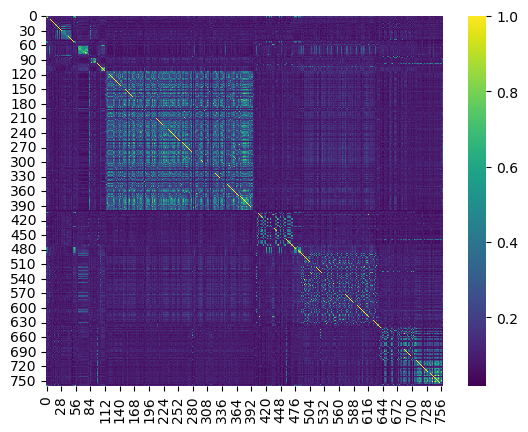

In [14]:
#Tanimoto similarity train set
sns.heatmap(similarity_matrix, cmap='viridis');

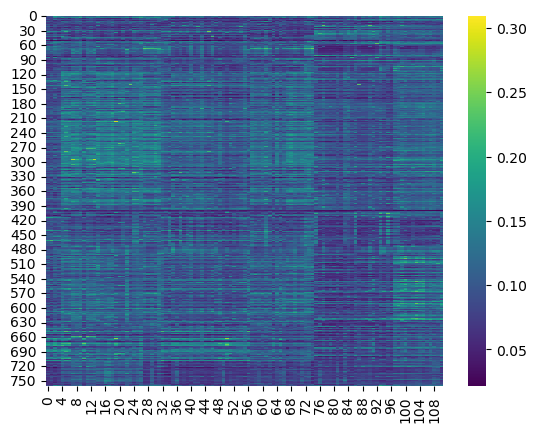

In [30]:
#Tanimoto similarity train vs. test set
sns.heatmap(similarity_matrix, cmap='viridis');

In [11]:
#Calculating AD with RDKit function and ExplicitBitVector:
from rdkit import DataStructs
import numpy as np

def calculate_domain_applicability_tanimoto_rdkit(X_train, X_test, threshold_percentile=80):
    """
    Domain applicability based on nearest-neighbor Tanimoto similarity.
    
    X_train, X_test: lists of RDKit ExplicitBitVect fingerprints
    """
    print(f"Calculating Tanimoto similarity for {len(X_train)} training and {len(X_test)} test molecules...")

    # Training nearest-neighbor similarity within training set
    similarities_train = np.zeros(len(X_train), dtype=float)
    for i, fp in enumerate(X_train):
        sims = DataStructs.BulkTanimotoSimilarity(fp, X_train)
        sims[i] = 0.0  # exclude self-similarity
        similarities_train[i] = max(sims)

    threshold_tanimoto = np.percentile(similarities_train, threshold_percentile)

    # Test nearest-neighbor similarity to training set
    similarities_test = np.array([
        max(DataStructs.BulkTanimotoSimilarity(fp, X_train))
        for fp in X_test
    ], dtype=float)

    inside_domain = similarities_test >= threshold_tanimoto

    return inside_domain, similarities_test, threshold_tanimoto, similarities_train

In [15]:
inside_domain_tanimoto, similarities_test, threshold_tanimoto, similarities_train = calculate_domain_applicability_tanimoto_rdkit(
    FPs_tr, FPs_ts, threshold_percentile=70
)

inside_count = np.sum(inside_domain_tanimoto)
outside_count = len(FPs_ts) - inside_count

print("\n" + "="*60)
print("="*60)
print(f"Tanimoto threshold (80th percentile of training): {threshold_tanimoto:.4f}")
print("\nTest set distribution:")
print(f"  INSIDE domain: {inside_count} ({inside_count/len(FPs_ts)*100:.1f}%)")
print(f"  OUTSIDE domain: {outside_count} ({outside_count/len(FPs_ts)*100:.1f}%)")

Calculating Tanimoto similarity for 760 training and 111 test molecules...

Tanimoto threshold (80th percentile of training): 0.7547

Test set distribution:
  INSIDE domain: 0 (0.0%)
  OUTSIDE domain: 111 (100.0%)


In [16]:
print(type(FPs_tr), type(FPs_tr[0]))
print(type(FPs_ts), type(FPs_ts[0]))

<class 'list'> <class 'rdkit.DataStructs.cDataStructs.ExplicitBitVect'>
<class 'list'> <class 'rdkit.DataStructs.cDataStructs.ExplicitBitVect'>


/tmp/ipykernel_19483/3971123684.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data_to_plot, labels=['Training', 'Test'], patch_artist=True)


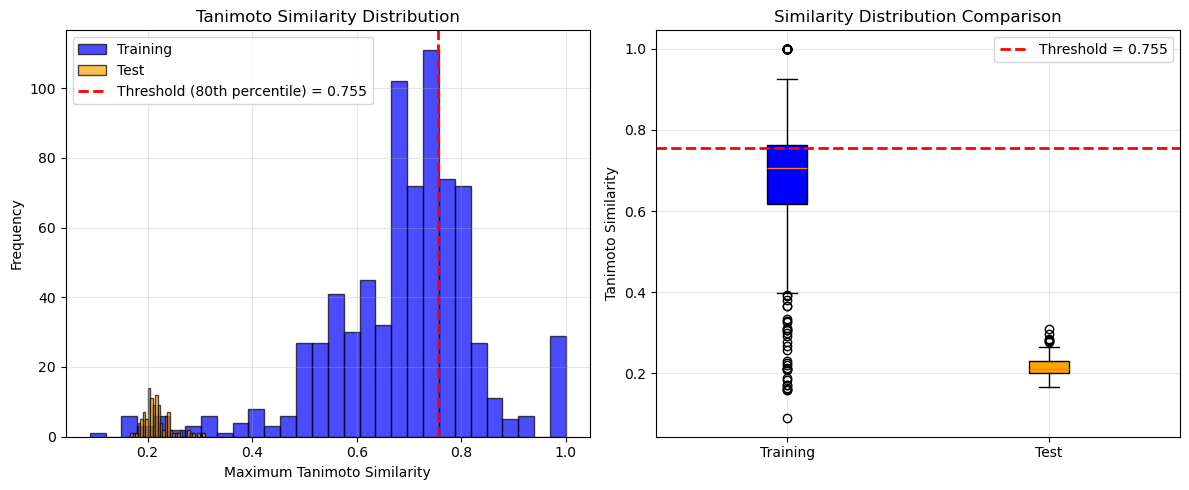

In [17]:
# ============================================================================
# VISUALIZE THE DISTRIBUTION
# ============================================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(similarities_train, bins=30, alpha=0.7, label='Training', color='blue', edgecolor='black')
plt.hist(similarities_test, bins=30, alpha=0.7, label='Test', color='orange', edgecolor='black')
plt.axvline(threshold_tanimoto, color='red', linestyle='--', linewidth=2, 
            label=f'Threshold (80th percentile) = {threshold_tanimoto:.3f}')
plt.xlabel('Maximum Tanimoto Similarity')
plt.ylabel('Frequency')
plt.title('Tanimoto Similarity Distribution')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# Box plot comparison
data_to_plot = [similarities_train, similarities_test]
bp = plt.boxplot(data_to_plot, labels=['Training', 'Test'], patch_artist=True)
bp['boxes'][0].set_facecolor('blue')
bp['boxes'][1].set_facecolor('orange')
plt.axhline(threshold_tanimoto, color='red', linestyle='--', linewidth=2,
            label=f'Threshold = {threshold_tanimoto:.3f}')
plt.ylabel('Tanimoto Similarity')
plt.title('Similarity Distribution Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# **Using Numpy array of features:**

In [18]:
# Set random seed for reproducibility
np.random.seed(42)

In [19]:
df = pd.read_csv("morganFP_2048.csv")
df

,0,1,2,3,4,5,6,7,8,9,...,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
755,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
756,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
757,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
758,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [20]:
df_class = pd.read_csv("ido_tdo.csv" , index_col=0)
df_class

,ido_tdo
0,AA
1,II
2,AI
3,II
4,II
...,...
755,II
756,II
757,IA
758,AI


In [21]:
y = df_class.values.reshape(len(df),)
y.shape

(760,)

In [22]:
encoder = LabelEncoder()
y_label = encoder.fit_transform(y)
y_label

array([0, 3, 1, 3, 3, 3, 2, 3, 3, 3, 2, 3, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1,
       3, 3, 3, 3, 3, 3, 3, 2, 2, 3, 0, 2, 3, 3, 1, 2, 1, 2, 3, 3, 2, 3,
       3, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 3, 1, 3, 3, 3, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 0, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1,
       3, 1, 1, 3, 1, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 2, 0, 1, 3, 0, 0,
       1, 3, 0, 2, 1, 3, 3, 1, 0, 1, 0, 0, 0, 0, 1, 3, 1, 0, 0, 0, 1, 0,
       3, 1, 0, 0, 1, 0, 2, 0, 0, 0, 1, 0, 0, 1, 1, 3, 0, 0, 3, 0, 0, 3,
       0, 1, 2, 1, 0, 0, 0, 0, 2, 2, 1, 0, 1, 0, 3, 0, 0, 0, 0, 0, 3, 0,
       0, 1, 1, 2, 0, 0, 0, 1, 0, 0, 3, 1, 1, 2, 0, 3, 3, 0, 0, 3, 0, 3,
       0, 3, 3, 3, 0, 0, 0, 1, 1, 1, 1, 0, 2, 0, 3, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 0, 3, 0, 3, 3, 3, 2, 2, 0, 1, 0, 2, 3, 0, 0, 1, 0, 0, 0,
       3, 3, 0, 0, 3, 3, 1, 2, 3, 0, 3, 0, 2, 0, 1, 3, 1, 0, 0, 3, 3, 0,
       0, 2, 1, 0, 3, 0, 3, 3, 0, 3, 3, 1, 1, 3, 3,

In [23]:
X = df.iloc[:, :]
X

,0,1,2,3,4,5,6,7,8,9,...,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
755,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
756,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
757,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
758,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [34]:
mapping = {'AA': 0, 'AI': 1, 'IA': 2, 'II': 3}
#External test:
df_test = pd.read_csv("test_morganFP_2048.csv")
df_test_class = pd.read_csv("testdata_target.csv")
y_t = df_test_class.iloc[:,-1]
X_t = df_test.iloc[:, :]

In [54]:
#Calculating DA with Leverage method:
'''Leverage is most appropriate when you have a continuous descriptor matrix and a regression-style model, 
because it is based on the hat matrix and extrapolation in feature space. 
It is a classical and interpretable AD approach for detecting structural extrapolation, 
so it can be a good choice if your features are numeric descriptors rather than binary fingerprints.'''

'Leverage is most appropriate when you have a continuous descriptor matrix and a regression-style model, \nbecause it is based on the hat matrix and extrapolation in feature space. \nIt is a classical and interpretable AD approach for detecting structural extrapolation, \nso it can be a good choice if your features are numeric descriptors rather than binary fingerprints.'

In [24]:
#Another method by Perplexity (Tanimoto similarity by custom numpy functions):
#Can act on both ExplicitBitVect and numpy array
import numpy as np

def tanimoto_similarity_matrix(X_a, X_b):
    X_a = np.asarray(X_a, dtype=np.uint8)
    X_b = np.asarray(X_b, dtype=np.uint8)

    intersection = X_a @ X_b.T
    sum_a = X_a.sum(axis=1, keepdims=True)
    sum_b = X_b.sum(axis=1, keepdims=True).T
    union = sum_a + sum_b - intersection

    return np.divide(intersection, union, out=np.zeros_like(intersection, dtype=float), where=union != 0)

def calculate_domain_applicability_tanimoto(X_train, X_test, threshold_percentile=1):
    X_train = np.asarray(X_train, dtype=np.uint8)
    X_test = np.asarray(X_test, dtype=np.uint8)

    train_sim = tanimoto_similarity_matrix(X_train, X_train)
    np.fill_diagonal(train_sim, 0.0)
    train_nn = train_sim.max(axis=1)
    threshold = np.percentile(train_nn, threshold_percentile)

    test_sim = tanimoto_similarity_matrix(X_test, X_train)
    test_nn = test_sim.max(axis=1)
    inside_domain = test_nn >= threshold

    return inside_domain, test_nn, threshold, train_nn

In [28]:
#I did not use SciPy or scikit-learn’s built-in Tanimoto function in that code. 
#I wrote a manual binary-fingerprint Tanimoto implementation with NumPy matrix operations instead.
#For Morgan bit vectors, Tanimoto/Jaccard similarity is computed as ∣A∩B∣/∣A∪B∣∣A∩B∣/∣A∪B∣, which is exactly what the NumPy code is doing with intersection / union. 
#So the formula itself is fine even without SciPy or scikit-learn, as long as the inputs are truly binary fingerprints.

In [31]:
inside_domain_tanimoto, similarities_test, threshold_tanimoto, similarities_train = calculate_domain_applicability_tanimoto(
    X, X_t, threshold_percentile=70
)

inside_count = np.sum(inside_domain_tanimoto)
outside_count = len(FPs_ts) - inside_count

print("\n" + "="*60)
print("="*60)
print(f"Tanimoto threshold (80th percentile of training): {threshold_tanimoto:.4f}")
print("\nTest set distribution:")
print(f"  INSIDE domain: {inside_count} ({inside_count/len(FPs_ts)*100:.1f}%)")
print(f"  OUTSIDE domain: {outside_count} ({outside_count/len(FPs_ts)*100:.1f}%)")


Tanimoto threshold (80th percentile of training): 0.7500

Test set distribution:
  INSIDE domain: 0 (0.0%)
  OUTSIDE domain: 111 (100.0%)


In [32]:
print(inside_domain_tanimoto.dtype)
print(similarities_test.min(), similarities_test.mean(), similarities_test.max())
print(similarities_train.min(), similarities_train.mean(), similarities_train.max())

bool
0.1414141414141414 0.1999691789516669 0.3
0.08108108108108109 0.6796230907822821 1.0


/tmp/ipykernel_19483/546576128.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data_to_plot, labels=['Training', 'Test'], patch_artist=True)


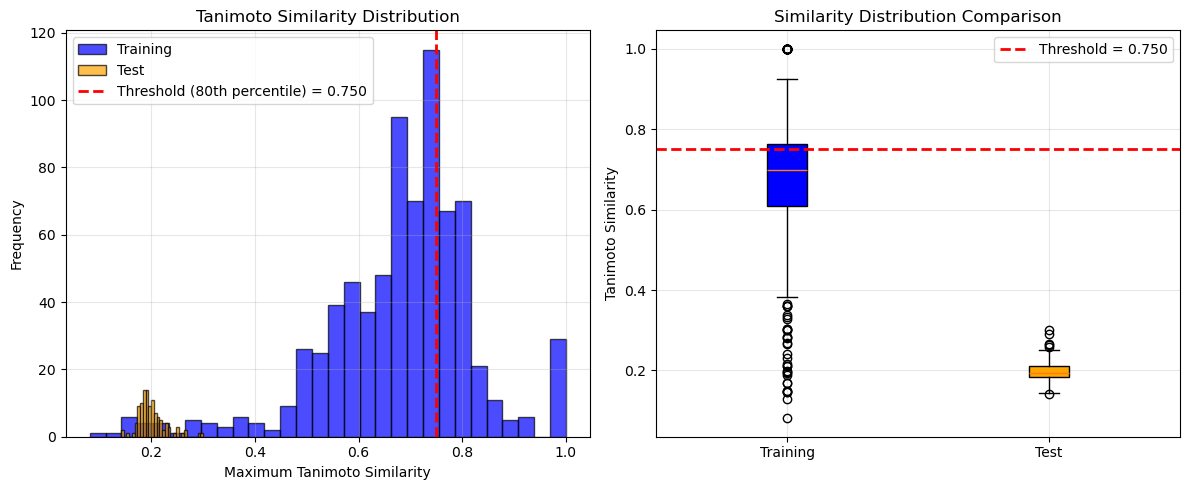


SUMMARY OF TEST MOLECULES BY DOMAIN STATUS

Test molecules with highest similarity:
     Similarity  Inside_Domain
12     0.300000          False
8      0.290000          False
5      0.265957          False
0      0.263889          False
19     0.258065          False
45     0.250000          False
7      0.250000          False
50     0.247423          False
103    0.242424          False
24     0.232323          False

Test molecules with lowest similarity (outside domain):
     Similarity  Inside_Domain
82     0.141414          False
81     0.144330          False
78     0.156627          False
76     0.164384          False
108    0.168224          False
79     0.168539          False
83     0.170000          False
94     0.172043          False
41     0.173469          False
80     0.173913          False

✅ Domain applicability analysis complete!
   0 molecules are INSIDE the domain
   111 molecules are OUTSIDE the domain


In [33]:
# ============================================================================
# VISUALIZE THE DISTRIBUTION
# ============================================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(similarities_train, bins=30, alpha=0.7, label='Training', color='blue', edgecolor='black')
plt.hist(similarities_test, bins=30, alpha=0.7, label='Test', color='orange', edgecolor='black')
plt.axvline(threshold_tanimoto, color='red', linestyle='--', linewidth=2, 
            label=f'Threshold (80th percentile) = {threshold_tanimoto:.3f}')
plt.xlabel('Maximum Tanimoto Similarity')
plt.ylabel('Frequency')
plt.title('Tanimoto Similarity Distribution')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# Box plot comparison
data_to_plot = [similarities_train, similarities_test]
bp = plt.boxplot(data_to_plot, labels=['Training', 'Test'], patch_artist=True)
bp['boxes'][0].set_facecolor('blue')
bp['boxes'][1].set_facecolor('orange')
plt.axhline(threshold_tanimoto, color='red', linestyle='--', linewidth=2,
            label=f'Threshold = {threshold_tanimoto:.3f}')
plt.ylabel('Tanimoto Similarity')
plt.title('Similarity Distribution Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# CHECK WHICH TEST MOLECULES ARE INSIDE DOMAIN
# ============================================================================
print("\n" + "="*60)
print("SUMMARY OF TEST MOLECULES BY DOMAIN STATUS")
print("="*60)

# If X_t is a DataFrame with molecule IDs, you can show them
if isinstance(X_t, pd.DataFrame):
    # Create a summary DataFrame
    summary_df = pd.DataFrame({
        'Similarity': similarities_test,
        'Inside_Domain': inside_domain_tanimoto
    })
    if hasattr(X_t, 'index') and X_t.index is not None:
        summary_df.index = X_t.index
    
    print("\nTest molecules with highest similarity:")
    print(summary_df.sort_values('Similarity', ascending=False).head(10))
    
    print("\nTest molecules with lowest similarity (outside domain):")
    print(summary_df.sort_values('Similarity', ascending=True).head(10))

print(f"\n✅ Domain applicability analysis complete!")
print(f"   {sum(inside_domain_tanimoto)} molecules are INSIDE the domain")
print(f"   {sum(~inside_domain_tanimoto)} molecules are OUTSIDE the domain")

In [28]:
# ============================================================================
# ADDITIONAL: Try with different thresholds
# ============================================================================
print("\n" + "="*60)
print("TRYING DIFFERENT THRESHOLDS")
print("="*60)

for percentile in [1, 10, 30, 50, 70, 80]:
    inside, _, _, _ = calculate_domain_applicability_tanimoto(
        FPs_tr, FPs_ts, threshold_percentile=percentile
    )
    pct_inside = sum(inside)/len(FPs_ts)*100
    print(f"Percentile {percentile}%: {sum(inside)} points inside ({pct_inside:.1f}%)")


TRYING DIFFERENT THRESHOLDS
Percentile 1%: 104 points inside (93.7%)
Percentile 10%: 0 points inside (0.0%)
Percentile 30%: 0 points inside (0.0%)
Percentile 50%: 0 points inside (0.0%)
Percentile 70%: 0 points inside (0.0%)
Percentile 80%: 0 points inside (0.0%)
